In [2]:
# importing necessary packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

In [3]:
# reading in files 
LIB = pd.read_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/DATA/LIB.csv', index_col='mag_id')
TFIDF_L2 = pd.read_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/DATA/TFIDF_L2.csv',index_col='mag_id')

# Riff 1

In [4]:
LIB

,epub_id,date,pages,month,quarter,page_num,title,character_len
mag_id,,,,,,,,
0,vo8DAAAAMBAJ,1972-12-07,"[""\n\n\n\nThis book was produced in EPUB forma...",12,4th Quarter,68,What Dope Arrest is Doing to Career of Barbara...,99374
1,ProDAAAAMBAJ,1967-05-11,"[""\n\n\n\nThis book was produced in EPUB forma...",5,2nd Quarter,68,What's Behind Suicide of Charles Diggs Sr.?,74986
2,dEIDAAAAMBAJ,1975-11-20,"[""\n\n\n\nThis book was produced in EPUB forma...",11,4th Quarter,68,Tito Jackson: His Music and His Family,89009
3,YEIDAAAAMBAJ,1978-05-04,"[""\n\n\n\nThis book was produced in EPUB forma...",5,2nd Quarter,68,New Reggie Defends His Hero Image,85341
4,AMADAAAAMBAJ,1978-07-06,"[""\n\n\n\nThis book was produced in EPUB forma...",7,3rd Quarter,68,Benson Shares His Fame With Family,89396
5,JEMDAAAAMBAJ,1951-11-01,"[""\n\n\n\nThis book was produced in EPUB forma...",11,4th Quarter,68,Ten Ways to Get a Mink Coat/ Why Negro Suicide...,81741
6,vq8DAAAAMBAJ,1960-03-10,"[""\n\n\n\nThis book was produced in EPUB forma...",3,1st Quarter,68,How Negroes Feel about a Catholic for US Presi...,79252
7,fbcDAAAAMBAJ,1958-02-20,"[""\n\n\n\nThis book was produced in EPUB forma...",2,1st Quarter,68,Rudy McCollum Talks Ends 5-Year Silence in Ins...,74909
8,YkEDAAAAMBAJ,1959-08-20,"[""\n\n\n\nThis book was produced in EPUB forma...",8,3rd Quarter,68,First Poll Reveals Candidates Negroes Want for...,78302


In [5]:
LIB['date'] = pd.to_datetime(LIB['date'], format ="%Y-%m-%d")
LIB['date']

mag_id
0   1972-12-07
1   1967-05-11
2   1975-11-20
3   1978-05-04
4   1978-07-06
5   1951-11-01
6   1960-03-10
7   1958-02-20
8   1959-08-20
9   1959-04-09
Name: date, dtype: datetime64[ns]

In [6]:
def plot_doc_in_terms(t1, t2):
    from matplotlib.patches import Patch
    ax = TFIDF_L2.plot.scatter(t1, t2, figsize=(10,10))
    for i, row in TFIDF_L2.iterrows():
        label = LIB.index.get_level_values('mag_id')[i]
        year = LIB.loc[i].date
        color = 'green' if (pd.Timestamp('1951-01-01') <= year <= pd.Timestamp('1964-12-31')) else 'blue'
        x_pad = TFIDF_L2[t1].max() * .01
        ax.annotate(label, xy=(row[t1] + x_pad, row[t2]),c=color)
    sns.despine()
    plt.title("Documents in Term Space", fontweight='bold')
    legend_elements = [Patch(facecolor='green', label='1951 to 1964'),
                       Patch(facecolor='blue', label='1964 onwards')]
    ax.legend(handles=legend_elements)
    plt.show()

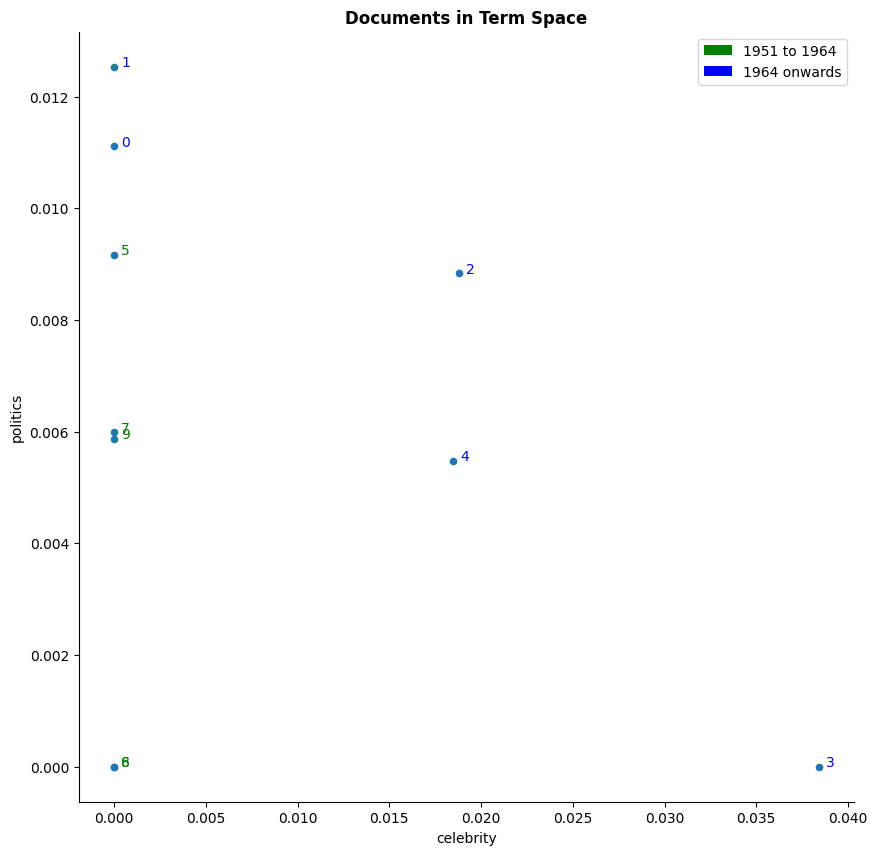

In [7]:
plot_doc_in_terms('celebrity', 'politics')

# Riff 2

In [8]:
PAIRS = pd.DataFrame(index=pd.MultiIndex.from_product([LIB.index.tolist(), LIB.index.tolist()])).reset_index()
PAIRS

,level_0,level_1
0,0,0
1,0,1
2,0,2
3,0,3
4,0,4
...,...,...
95,9,5
96,9,6
97,9,7
98,9,8


In [9]:
# Keep only unique pairs of different books
PAIRS = PAIRS[PAIRS.level_0 < PAIRS.level_1].set_index(['level_0','level_1'])
PAIRS

Empty DataFrame
Columns: []
Index: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 6), (5, 7), (5, 8), (5, 9), (6, 7), (6, 8), (6, 9), (7, 8), (7, 9), (8, 9)]

In [10]:
# Name index cols
PAIRS.index.names = ['doc_a', 'doc_b']
PAIRS.shape

(45, 0)

In [11]:
TFIDF_SIGS = pd.read_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/DATA/TFIDF_SIGS.csv', index_col='mag_id')
TFIDF_SIGS

,aaron,abandoned,abc,ability,able,aboard,abortion,above,abroad,abruptly,...,yourself,youthful,youthfullooking,youths,ypsilanti,yvonne,zion,zip,zone,zurich
mag_id,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,1.000000,2.0,1.711181,0.000000,0.000000,0.000000,1.321928,0.000000,...,0.736966,1.736966,0.000000,1.029146,2.321928,0.000000,1.321928,5.210897,0.000000,0.000000
1,1.321928,0.000000,1.000000,1.0,0.000000,2.321928,0.000000,1.168063,0.000000,0.000000,...,0.736966,0.000000,2.321928,0.000000,0.000000,0.514573,1.321928,2.753025,0.000000,0.000000
2,0.000000,2.321928,1.584963,0.0,0.000000,0.000000,1.321928,1.711181,0.000000,0.000000,...,1.905028,0.000000,0.000000,1.029146,0.000000,0.514573,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,3.000000,1.0,1.168063,0.000000,0.000000,0.736966,0.000000,1.321928,...,0.736966,0.000000,2.321928,0.514573,2.321928,0.514573,0.000000,1.736966,0.000000,0.000000
4,0.000000,0.000000,2.584963,1.0,1.473931,0.000000,1.321928,0.000000,0.000000,0.000000,...,0.736966,0.000000,0.000000,0.000000,0.000000,0.815579,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.0,0.736966,0.000000,2.095206,0.000000,1.321928,1.321928,...,0.000000,0.000000,0.000000,0.514573,0.000000,0.000000,2.095206,0.000000,1.321928,0.000000
6,2.643856,0.000000,0.000000,0.0,1.168063,0.000000,0.000000,0.000000,1.321928,0.000000,...,0.736966,0.000000,0.000000,0.815579,0.000000,0.514573,0.000000,0.000000,0.000000,2.095206
7,3.711121,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.168063,2.095206,1.321928,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.514573,0.000000,0.000000,1.321928,1.321928
8,1.321928,2.321928,0.000000,1.0,0.000000,2.321928,1.321928,0.736966,0.000000,1.321928,...,0.000000,1.736966,0.000000,1.330152,0.000000,0.000000,0.000000,0.000000,2.643856,1.321928


In [12]:
# now computing the distance
pdist(TFIDF_SIGS, 'cosine')

array([0.76973616, 0.74277734, 0.76243401, 0.77461933, 0.81306176,
       0.80469765, 0.82733491, 0.81047665, 0.82798003, 0.79935056,
       0.80432229, 0.79099705, 0.82271861, 0.80325277, 0.82682588,
       0.81181854, 0.81419148, 0.74519263, 0.7534671 , 0.81579895,
       0.82661766, 0.82622545, 0.81920502, 0.81309109, 0.71415587,
       0.82725568, 0.85009419, 0.84194944, 0.83131593, 0.83872978,
       0.83079884, 0.84669316, 0.82637726, 0.81915091, 0.82035111,
       0.79027361, 0.79159087, 0.79145496, 0.77419878, 0.76604597,
       0.74406254, 0.77688535, 0.76841514, 0.75218927, 0.7681672 ])

In [13]:
PAIRS['cityblock'] = pdist(TFIDF_SIGS, 'cityblock')
PAIRS['cityblock2'] = pdist(TFIDF_L2, 'cityblock')
PAIRS['euclidean'] = pdist(TFIDF_SIGS, 'euclidean')
PAIRS['euclidean2'] = pdist(TFIDF_L2, 'euclidean') # Should be the same as cosine (colinear)
PAIRS['cosine'] = pdist(TFIDF_SIGS, 'cosine')
PAIRS['cosine2'] = pdist(TFIDF_L2, 'cosine')

In [14]:
def hac(sim_method='cosine', linkage_method='complete', color_thresh=.3, figsize=(10, 10)):

    # Get the similarities among pairs
    sims = PAIRS[sim_method]
    
    # Generate the cluster tree
    tree = sch.linkage(sims, method=linkage_method)
    
    # Get labels for the leaves
    labels = LIB.title.values 

    # Create a dendrogram from the tree
    sch.dendrogram(tree, 
        labels=labels, 
        orientation="left", 
        count_sort=True,
        distance_sort=True,
        above_threshold_color='.75',
        color_threshold=color_thresh
    )

    # Show threshhold
    ax = plt.gca()
    ax.axvline(color_thresh, c='gray', ls='--')

    # Change the appearance of ticks, tick labels, and gridlines
    plt.tick_params(axis='both', which='major', labelsize=10)    

    # Remove borders
    sns.despine(left=True, bottom=True)

    # Add title
    plt.title(f"{sim_method} + {linkage_method} ({color_thresh})", y=1.05)

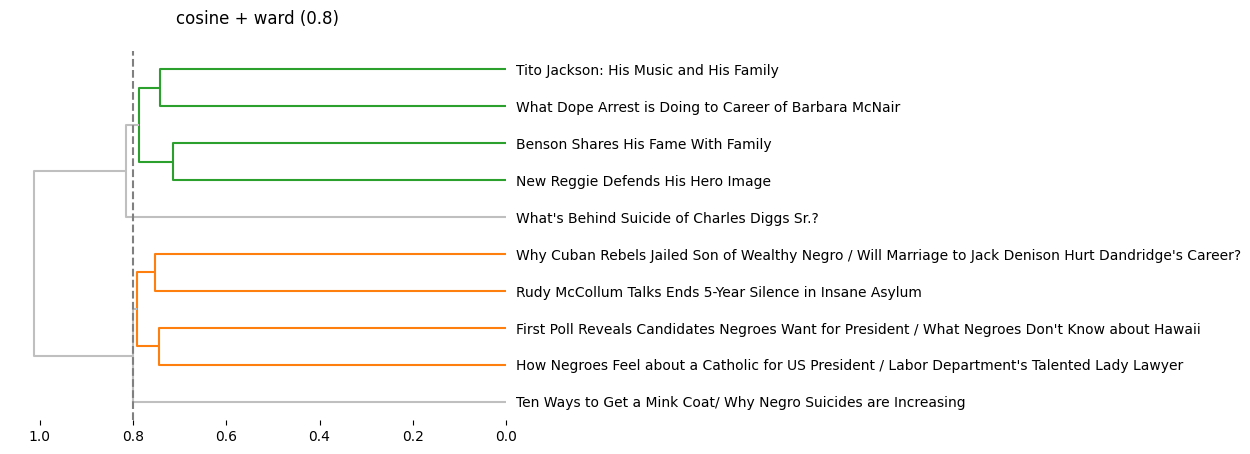

In [15]:
hac('cosine', 'ward', color_thresh=0.8)

# Riff 3 

In [17]:
LIB.sort_values(by='date')

,epub_id,date,pages,month,quarter,page_num,title,character_len
mag_id,,,,,,,,
5,JEMDAAAAMBAJ,1951-11-01,"[""\n\n\n\nThis book was produced in EPUB forma...",11,4th Quarter,68,Ten Ways to Get a Mink Coat/ Why Negro Suicide...,81741
7,fbcDAAAAMBAJ,1958-02-20,"[""\n\n\n\nThis book was produced in EPUB forma...",2,1st Quarter,68,Rudy McCollum Talks Ends 5-Year Silence in Ins...,74909
9,mEEDAAAAMBAJ,1959-04-09,"[""\n\n\n\nThis book was produced in EPUB forma...",4,2nd Quarter,68,Why Cuban Rebels Jailed Son of Wealthy Negro /...,76401
8,YkEDAAAAMBAJ,1959-08-20,"[""\n\n\n\nThis book was produced in EPUB forma...",8,3rd Quarter,68,First Poll Reveals Candidates Negroes Want for...,78302
6,vq8DAAAAMBAJ,1960-03-10,"[""\n\n\n\nThis book was produced in EPUB forma...",3,1st Quarter,68,How Negroes Feel about a Catholic for US Presi...,79252
1,ProDAAAAMBAJ,1967-05-11,"[""\n\n\n\nThis book was produced in EPUB forma...",5,2nd Quarter,68,What's Behind Suicide of Charles Diggs Sr.?,74986
0,vo8DAAAAMBAJ,1972-12-07,"[""\n\n\n\nThis book was produced in EPUB forma...",12,4th Quarter,68,What Dope Arrest is Doing to Career of Barbara...,99374
2,dEIDAAAAMBAJ,1975-11-20,"[""\n\n\n\nThis book was produced in EPUB forma...",11,4th Quarter,68,Tito Jackson: His Music and His Family,89009
3,YEIDAAAAMBAJ,1978-05-04,"[""\n\n\n\nThis book was produced in EPUB forma...",5,2nd Quarter,68,New Reggie Defends His Hero Image,85341
